# 01 · Autoencoder Fundamentals — Compression, Reconstruction & the Bottleneck

Welcome! This is the **first** notebook of a hands-on series on **Autoencoders (AEs)**. By the end
of the series you will understand *what* the main autoencoder variants are, *why* each one exists,
and — crucially for a consulting interview — *which real problem each one solves*.

This first notebook is about **pure understanding**. We use a tiny, fully-offline dataset and a
small network so everything runs in seconds on a CPU. The goal is that you can *draw the picture
on a whiteboard* and explain every arrow.

**What you will learn here**

1. The **one idea** behind every autoencoder: *learn to reconstruct your input through a bottleneck.*
2. The three parts — **encoder → latent code (bottleneck) → decoder** — and the **reconstruction loss**.
3. Why "copying the input" is not trivial and actually forces the model to **learn structure**.
4. Build and train your **first autoencoder** in PyTorch on 8×8 digit images.
5. Read the **latent space**: a 2-D map where similar inputs land near each other.
6. The deep connection to **PCA**: *a linear autoencoder with MSE loss is PCA* — and where AEs go beyond it.

> Framework: **PyTorch**, CPU-only. Data: `sklearn.load_digits` (bundled, **no download**).


In [ ]:
# Only the essentials. Everything here runs on CPU in seconds.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)   # reproducibility: same weights & shuffles every run
np.random.seed(0)

print("torch", torch.__version__, "| device: CPU")

## 1. The one big idea: learn to copy yourself — but through a narrow pipe

An **autoencoder** is a neural network trained to output **a copy of its own input**. That sounds
useless — why train a network to return what you already have? The trick is the **shape** of the
network: we force the information through a **narrow middle layer** called the **bottleneck** (or
*latent code*, or *code*).

The whole series fits in one picture — run the cell below to draw it: an image `x` goes in, the
**encoder** squeezes it down to a handful of numbers `z`, the **decoder** blows it back up to `x̂`,
and a single **reconstruction loss** compares the two ends.

Because the code `z` has **far fewer numbers** than the input, the network **cannot** simply pass
the data through untouched. To reconstruct `x` well from a tiny `z`, it must discover and keep only
the **essential structure** of the data and throw away noise and redundancy. That forced summary
*is* the useful thing an autoencoder produces.

Three named parts:

| Part | Symbol | Job |
|---|---|---|
| **Encoder** | $z = f(x)$ | compress the input into a small code |
| **Latent code / bottleneck** | $z$ | the compressed summary (the "understanding") |
| **Decoder** | $\hat{x} = g(z)$ | rebuild the input from the code |

And a single training objective — the **reconstruction loss** — pushes $\hat{x}$ to look like $x$:

$$ \mathcal{L}(x) = \big\lVert\, x - \hat{x} \,\big\rVert^2 = \big\lVert\, x - g(f(x)) \,\big\rVert^2 $$

That's it. No labels are needed — the input is its own target. Autoencoders are therefore a form of
**self-supervised / unsupervised learning**: they learn from the *structure* of the data alone.

In [ ]:
from matplotlib.patches import Polygon, Rectangle, FancyArrowPatch

ENC, DEC, CODE, INK = "#1a7f37", "#8250df", "#b30000", "#333333"

# A stand-in 8x8 digit so the schematic is self-contained (the real data arrives in section 3).
GLYPH = ["..####..", ".##..##.", "......#.", "...###..", "......#.", "......#.", ".##..##.", "..####.."]
x_img = np.array([[1.0 if c == "#" else 0.0 for c in row] for row in GLYPH])

def blur(a):
    """A cheap box blur — stands in for the blurry copy a 2-number code can afford to rebuild."""
    p = np.pad(a, 1)                                    # zeros outside = white background
    return sum(p[i:i+8, j:j+8] for i in range(3) for j in range(3)) / 9

xhat_img = 0.5 * x_img + 0.5 * blur(x_img)              # the gist survives, the fine detail smears


def draw_schematic():
    fig, ax = plt.subplots(figsize=(12, 5))

    # --- the two ends: the input image and the (blurry) reconstruction ----------
    ax.imshow(x_img,    cmap="gray_r", vmin=0, vmax=1, extent=(0.0, 2.0, -1.0, 1.0), zorder=3)
    ax.imshow(xhat_img, cmap="gray_r", vmin=0, vmax=1, extent=(11.6, 13.6, -1.0, 1.0), zorder=3)
    for x0, x1 in [(0.0, 2.0), (11.6, 13.6)]:
        ax.add_patch(Rectangle((x0, -1.0), x1 - x0, 2.0, fill=False, ec=INK, lw=1.4, zorder=4))
    ax.text(1.0,  1.35, "INPUT  $x$", ha="center", fontsize=13, weight="bold")
    ax.text(1.0, -1.35, "64 pixels",  ha="center", va="top", fontsize=10, color=INK)
    ax.text(12.6,  1.35, "RECONSTRUCTION  $\\hat{x}$", ha="center", fontsize=13, weight="bold")
    ax.text(12.6, -1.35, "64 pixels (blurry)", ha="center", va="top", fontsize=10, color=INK)

    # --- encoder: a funnel that narrows -----------------------------------------
    ax.add_patch(Polygon([(2.9, 1.6), (5.9, 0.55), (5.9, -0.55), (2.9, -1.6)],
                         closed=True, fc="#cfe8ff", ec=ENC, lw=2, zorder=2))
    ax.text(4.4, 0.0, "ENCODER\n$f(x)$", ha="center", va="center", fontsize=12,
            weight="bold", color=ENC, zorder=3)

    # --- the bottleneck: just a couple of numbers --------------------------------
    for k, name in enumerate(["$z_1$", "$z_2$"]):
        y = 0.42 - k * 0.84
        ax.add_patch(Rectangle((6.45, y - 0.32), 0.7, 0.64, fc="#ffd9d9", ec=CODE, lw=2, zorder=3))
        ax.text(6.8, y, name, ha="center", va="center", fontsize=12, color=CODE, zorder=4)
    ax.text(6.8,  1.35, "CODE  $z$", ha="center", fontsize=13, weight="bold", color=CODE)
    ax.text(6.8, -1.35, "2 numbers\n(the bottleneck)", ha="center", va="top",
            fontsize=10, color=CODE)

    # --- decoder: the mirrored funnel that widens --------------------------------
    ax.add_patch(Polygon([(7.7, 0.55), (10.7, 1.6), (10.7, -1.6), (7.7, -0.55)],
                         closed=True, fc="#ece2ff", ec=DEC, lw=2, zorder=2))
    ax.text(9.2, 0.0, "DECODER\n$g(z)$", ha="center", va="center", fontsize=12,
            weight="bold", color=DEC, zorder=3)

    # --- flow arrows -------------------------------------------------------------
    for x0, x1 in [(2.1, 2.8), (6.0, 6.35), (7.25, 7.6), (10.8, 11.5)]:
        ax.annotate("", xy=(x1, 0), xytext=(x0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=1.8, color=INK))

    # --- what each half does to the information ----------------------------------
    ax.annotate("", xy=(5.9, 2.15), xytext=(2.9, 2.15),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color=ENC))
    ax.text(4.4, 2.35, "compress  (64 → 2)", ha="center", fontsize=11, color=ENC)
    ax.annotate("", xy=(10.7, 2.15), xytext=(7.7, 2.15),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color=DEC))
    ax.text(9.2, 2.35, "expand  (2 → 64)", ha="center", fontsize=11, color=DEC)

    # --- the training signal: the two ends are compared, nothing else -------------
    for x in (1.0, 12.6):
        ax.plot([x, x], [-1.9, -3.2], ls=":", lw=1.4, color=CODE, zorder=1)
    ax.add_patch(FancyArrowPatch((1.0, -3.2), (12.6, -3.2), arrowstyle="<|-|>",
                                 mutation_scale=14, lw=1.6, ls="--", color=CODE, zorder=1))
    ax.text(6.8, -3.55, "reconstruction loss   $\\mathcal{L} = \\| x - \\hat{x} \\|^2$"
                        "   →  the ONLY thing we train on (no labels)",
            ha="center", va="top", fontsize=12, color=CODE)

    ax.set_xlim(-0.6, 14.2); ax.set_ylim(-4.4, 3.0)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title("The autoencoder in one picture: squeeze it down, build it back, "
                 "score the difference", fontsize=13, pad=10)
    plt.tight_layout(); plt.show()

draw_schematic()

### Why this is powerful (the consulting angle)

You almost never deploy an autoencoder to "copy data". You deploy it for one of its **side effects**:

| You actually want… | You use the… | Example problem |
|---|---|---|
| a compact feature vector | **latent code `z`** | dimensionality reduction, visualization, features for another model |
| to know what "normal" looks like | **reconstruction error** | anomaly / fraud / fault detection (later notebook) |
| clean data | **decoder output** | denoising images/signals (later notebook) |
| to *generate* new data | a **structured latent space** | variational autoencoders (later notebook) |

Everything in this series is a variation on the same picture above — we change the **bottleneck**,
the **loss**, or **what we feed in vs. ask out**, and a new capability appears.


## 2. A picture is worth a thousand tensors — draw the architecture

Before any data, let's draw the classic **hourglass / funnel** shape of an undercomplete
autoencoder. The width of each layer is the number of neurons. Notice how it **narrows to the
bottleneck** and then **widens back out** — symmetric like an hourglass.


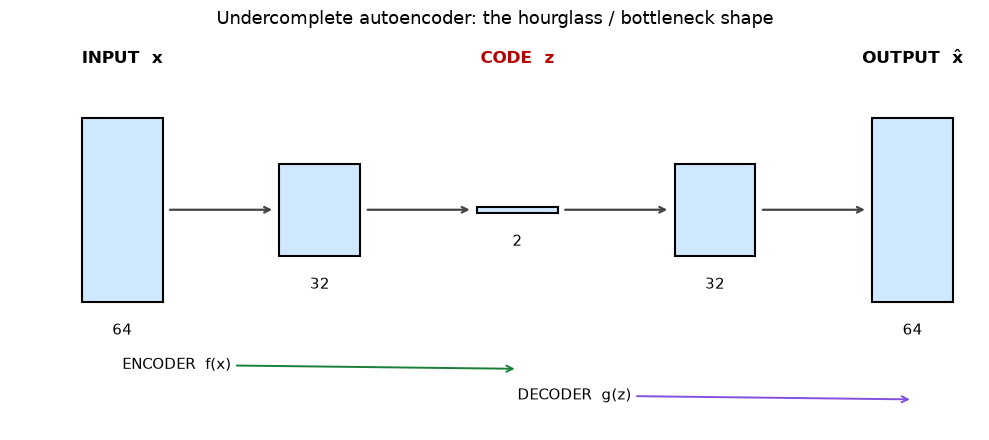

In [2]:
def draw_autoencoder(layer_sizes=(64, 32, 2, 32, 64)):
    """Draw an autoencoder as an hourglass: each column is a layer, height ~ #neurons."""
    fig, ax = plt.subplots(figsize=(10, 4.5))
    n_layers = len(layer_sizes)
    x_gap = 2.2
    max_h = max(layer_sizes)
    centers = []
    for i, size in enumerate(layer_sizes):
        x = i * x_gap
        h = size / max_h * 3.0          # visual height proportional to neuron count
        ax.add_patch(plt.Rectangle((x, -h/2), 0.9, h, fc="#cfe8ff", ec="black", lw=1.5))
        ax.text(x + 0.45, -h/2 - 0.35, str(size), ha="center", va="top", fontsize=11)
        centers.append((x + 0.45, 0))
    # arrows between layers
    for i in range(n_layers - 1):
        ax.annotate("", xy=(centers[i+1][0] - 0.5, 0), xytext=(centers[i][0] + 0.5, 0),
                    arrowprops=dict(arrowstyle="->", lw=1.6, color="#444"))
    # labels
    mid = n_layers // 2
    ax.text(centers[0][0], 2.4, "INPUT  x", ha="center", fontsize=12, weight="bold")
    ax.text(centers[mid][0], 2.4, "CODE  z", ha="center", fontsize=12, weight="bold", color="#b30000")
    ax.text(centers[-1][0], 2.4, "OUTPUT  x̂", ha="center", fontsize=12, weight="bold")
    ax.annotate("ENCODER  f(x)", xy=(centers[mid][0], -2.6),
                xytext=(centers[0][0], -2.6), ha="left", fontsize=11,
                arrowprops=dict(arrowstyle="->", color="#1a7f37", lw=1.4))
    ax.annotate("DECODER  g(z)", xy=(centers[-1][0], -3.1),
                xytext=(centers[mid][0], -3.1), ha="left", fontsize=11,
                arrowprops=dict(arrowstyle="->", color="#8250df", lw=1.4))
    ax.set_xlim(-0.8, (n_layers - 1) * x_gap + 1.2)
    ax.set_ylim(-3.6, 2.9)
    ax.axis("off")
    ax.set_title("Undercomplete autoencoder: the hourglass / bottleneck shape", fontsize=13)
    plt.tight_layout(); plt.show()

draw_autoencoder((64, 32, 2, 32, 64))


**Undercomplete** just means the bottleneck is *smaller* than the input (here 2 ≪ 64). That is
the most common and most useful case: the squeeze is what forces learning. (An *overcomplete*
autoencoder, with a bottleneck as big or bigger than the input, could cheat by copying — we'll see
in notebook 04 how **regularization** makes even those useful.)


## 3. The data: 8×8 handwritten digits (offline, tiny, perfect for intuition)

We use scikit-learn's bundled **`digits`** dataset: 1,797 grayscale images of handwritten digits,
each just **8×8 = 64 pixels**, values 0–16. It ships with scikit-learn, so **no download**. Small
enough to train an autoencoder in seconds, yet rich enough to show real structure in the latent
space.


X_train: (1437, 64) | X_test: (360, 64) | feature range: 0.0 to 1.0


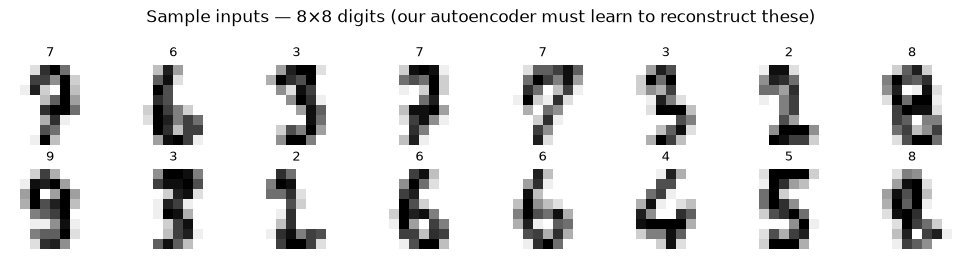

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.images                 # shape (1797, 8, 8), pixel values 0..16
y = digits.target                 # the digit 0..9 (used ONLY for coloring plots, never for training)

X = X.reshape(len(X), -1).astype("float32") / 16.0   # flatten to 64 features, scale to [0, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| feature range:", X.min(), "to", X.max())

# Peek at a few images
fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
for ax, img, lab in zip(axes.ravel(), X_test, y_test):
    ax.imshow(img.reshape(8, 8), cmap="gray_r"); ax.set_title(int(lab), fontsize=9); ax.axis("off")
fig.suptitle("Sample inputs — 8×8 digits (our autoencoder must learn to reconstruct these)")
plt.tight_layout(); plt.show()


> **Note on the labels `y`.** An autoencoder is *unsupervised* — we train it only on the pixels
`X`. We keep the digit labels `y` aside purely to **color the latent-space plot** later, so we can
*check* whether the unsupervised code discovered the digit structure on its own. The model never
sees `y`.


## 4. Build the autoencoder in PyTorch

We build the hourglass from the diagram: `64 → 32 → 2 → 32 → 64`. The **2-neuron bottleneck** is a
deliberate, extreme squeeze — it lets us *plot* the entire latent space on a flat page. We use
`ReLU` between hidden layers and a `Sigmoid` on the output so reconstructions land in `[0, 1]`
(matching our scaled pixels).


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=64, latent_dim=2):
        super().__init__()
        # ENCODER: squeeze 64 -> 32 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 32), 
            nn.ReLU(),
            nn.Linear(32, latent_dim),          # <-- the bottleneck (no activation: raw coordinates)
        )
        # DECODER: expand latent_dim -> 32 -> 64, mirror of the encoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), 
            nn.ReLU(),
            nn.Linear(32, in_dim), 
            nn.Sigmoid(),  # Sigmoid keeps outputs in [0, 1] like the inputs
        )

    def encode(self, x):
        return self.encoder(x)                  # -> the latent code z

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

model = Autoencoder(in_dim=64, latent_dim=2)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Sigmoid()
  )
)

Trainable parameters: 4,354


### The training loop

The target **is the input** (`x` in, `x` out). We minimise the **Mean Squared Error** between the
reconstruction `x̂` and the original `x`. This is ordinary supervised training — the twist is only
that we generate the labels for free from the data itself.


/data/pgcasado/projects/machine-learning-projects/venv/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch  20 | train MSE 0.0459 | test MSE 0.0470


epoch  40 | train MSE 0.0413 | test MSE 0.0439


epoch  60 | train MSE 0.0394 | test MSE 0.0426


epoch  80 | train MSE 0.0380 | test MSE 0.0411


epoch 100 | train MSE 0.0369 | test MSE 0.0403


epoch 120 | train MSE 0.0364 | test MSE 0.0401


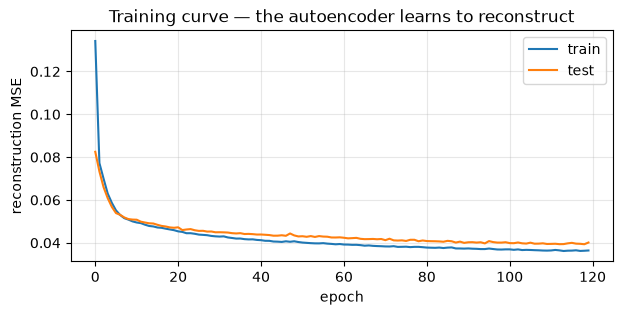

In [5]:
import torch.optim as optim

Xtr = torch.tensor(X_train)
Xte = torch.tensor(X_test)

model = Autoencoder(in_dim=64, latent_dim=2)
opt = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

EPOCHS, BATCH = 120, 128
n = len(Xtr)
history = {"train": [], "test": []}

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(n)                     # shuffle each epoch
    epoch_loss = 0.0
    for i in range(0, n, BATCH):
        idx = perm[i:i+BATCH]
        xb = Xtr[idx]
        x_hat, _ = model(xb)
        loss = loss_fn(x_hat, xb)                # reconstruct the INPUT itself
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item() * len(xb)
    # evaluate
    model.eval()
    with torch.no_grad():
        train_mse = epoch_loss / n
        test_mse = loss_fn(model(Xte)[0], Xte).item()
    history["train"].append(train_mse); history["test"].append(test_mse)
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:3d} | train MSE {train_mse:.4f} | test MSE {test_mse:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(history["train"], label="train")
plt.plot(history["test"], label="test")
plt.xlabel("epoch"); plt.ylabel("reconstruction MSE"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Training curve — the autoencoder learns to reconstruct"); plt.show()


## 5. Look at the reconstructions

With only **2 numbers** in the bottleneck, the network is forced to store a *drastic* summary of
each 64-pixel image. Reconstructions will be **blurry** — that's expected and instructive. The
autoencoder keeps the *gist* (rough shape/identity of the digit) and discards fine detail. Compare
top (original) vs. bottom (reconstruction):


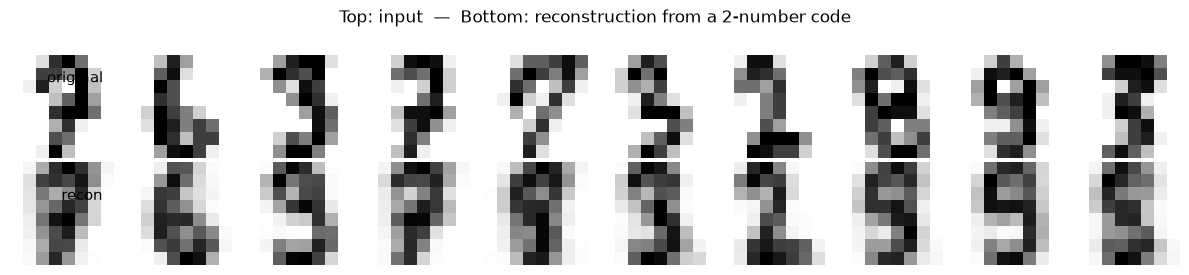

In [6]:
model.eval()
with torch.no_grad():
    recon, _ = model(Xte)
recon = recon.numpy()

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for j in range(10):
    axes[0, j].imshow(X_test[j].reshape(8, 8), cmap="gray_r"); axes[0, j].axis("off")
    axes[1, j].imshow(recon[j].reshape(8, 8),  cmap="gray_r"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("original", rotation=0, ha="right", va="center")
axes[1, 0].set_ylabel("recon",    rotation=0, ha="right", va="center")
fig.text(0.09, 0.72, "original", ha="right", fontsize=11)
fig.text(0.09, 0.30, "recon",    ha="right", fontsize=11)
fig.suptitle("Top: input  —  Bottom: reconstruction from a 2-number code")
plt.tight_layout(); plt.show()


## 6. Read the latent space — the payoff of the bottleneck

Because we chose a **2-D** bottleneck, we can plot the code `z` for every test image on a plane.
The autoencoder was **never told the digit labels**, yet if it learned real structure, images of the
same digit should cluster together. We color by the true label *only to check* — the layout itself
was discovered unsupervised.


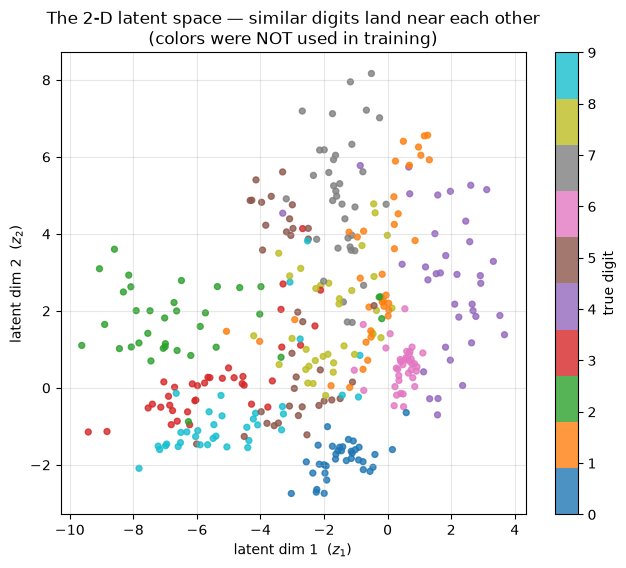

In [7]:
with torch.no_grad():
    Z = model.encode(Xte).numpy()      # (n_test, 2)

plt.figure(figsize=(7.5, 6))
sc = plt.scatter(Z[:, 0], Z[:, 1], c=y_test, cmap="tab10", s=18, alpha=0.8)
plt.colorbar(sc, label="true digit", ticks=range(10))
plt.xlabel("latent dim 1  ($z_1$)"); plt.ylabel("latent dim 2  ($z_2$)")
plt.title("The 2-D latent space — similar digits land near each other\n(colors were NOT used in training)")
plt.grid(alpha=0.3); plt.show()


**What to notice**

- The plane is organised into **regions** — the unsupervised code recovered a lot of the digit
  structure just by trying to reconstruct pixels.
- Some digits overlap (e.g. 3/8/9 look similar in 8×8). A 2-number summary simply *cannot* separate
  everything — there isn't room. Give the bottleneck more dimensions and separation improves (try it!).
- This is exactly why the latent code is useful as **features** for a downstream model, or as a
  **2-D map** for visualization — a theme we develop in notebook 04.


## 7. The deep connection: a *linear* autoencoder **is** PCA

Here is the single most important theoretical fact about autoencoders, and a classic interview
question:

> **A linear autoencoder (no activation functions) trained with MSE loss learns the same subspace
> as Principal Component Analysis (PCA).**

Intuition: PCA finds the `k`-dimensional linear subspace that captures the most variance — i.e. the
best *linear* reconstruction of the data. A linear autoencoder with a `k`-neuron bottleneck is
*also* searching for the best linear reconstruction. Same objective ⇒ same optimal subspace (the AE
can rotate/mix the axes, but it spans the same space).

So what do the **nonlinear** autoencoders we usually build buy us? They can bend the subspace into a
**curved manifold**, capturing structure PCA's straight subspace cannot. Let's demonstrate both
claims empirically: (a) linear-AE ≈ PCA, and (b) nonlinear AE < PCA reconstruction error.


In [8]:
from sklearn.decomposition import PCA

def linear_ae_reconstruction_mse(X_tr, X_te, k, epochs=300):
    """A purely LINEAR autoencoder (no activations): encoder and decoder are single matrices."""
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(64, k, bias=True), nn.Linear(k, 64, bias=True))
    opt = optim.Adam(net.parameters(), lr=5e-2)
    Xt = torch.tensor(X_tr)
    for _ in range(epochs):
        out = net(Xt); loss = ((out - Xt) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return ((net(torch.tensor(X_te)) - torch.tensor(X_te)) ** 2).mean().item()

def pca_reconstruction_mse(X_tr, X_te, k):
    p = PCA(n_components=k).fit(X_tr)
    rec = p.inverse_transform(p.transform(X_te))
    return ((rec - X_te) ** 2).mean()

def nonlinear_ae_reconstruction_mse(X_tr, X_te, k, epochs=400):
    """Nonlinear AE with ONE hidden layer whose width scales with k, so the hidden layer never
    becomes an accidental second bottleneck (its width is always >= k). No activation on the code."""
    torch.manual_seed(0)
    h = max(32, 2 * k)
    net = nn.Sequential(
        nn.Linear(64, h), nn.ReLU(), nn.Linear(h, k),          # encoder (code is raw, no ReLU)
        nn.Linear(k, h), nn.ReLU(), nn.Linear(h, 64), nn.Sigmoid(),  # decoder
    )
    opt = optim.Adam(net.parameters(), lr=1e-2)
    Xt = torch.tensor(X_tr)
    for _ in range(epochs):
        out = net(Xt); loss = ((out - Xt) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return ((net(torch.tensor(X_te)) - torch.tensor(X_te)) ** 2).mean().item()

ks = [2, 4, 8, 16, 32]
pca_mse   = [pca_reconstruction_mse(X_train, X_test, k)            for k in ks]
lin_mse   = [linear_ae_reconstruction_mse(X_train, X_test, k)     for k in ks]
nonlin_mse= [nonlinear_ae_reconstruction_mse(X_train, X_test, k)  for k in ks]

print(f"{'k':>3} | {'PCA':>8} | {'linear AE':>10} | {'nonlinear AE':>12}")
for k, a, b, c in zip(ks, pca_mse, lin_mse, nonlin_mse):
    print(f"{k:>3} | {a:8.4f} | {b:10.4f} | {c:12.4f}")


  k |      PCA |  linear AE | nonlinear AE
  2 |   0.0532 |     0.0532 |       0.0421
  4 |   0.0379 |     0.0379 |       0.0265
  8 |   0.0246 |     0.0252 |       0.0166
 16 |   0.0116 |     0.0118 |       0.0109
 32 |   0.0026 |     0.0038 |       0.0066


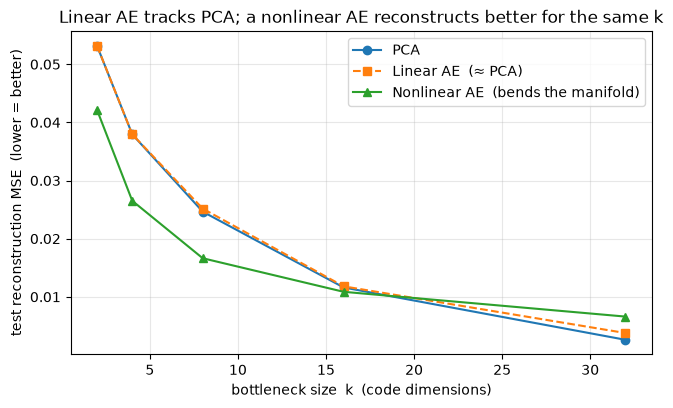

In [9]:
plt.figure(figsize=(7.5, 4.2))
plt.plot(ks, pca_mse,    "o-", label="PCA")
plt.plot(ks, lin_mse,    "s--", label="Linear AE  (≈ PCA)")
plt.plot(ks, nonlin_mse, "^-", label="Nonlinear AE  (bends the manifold)")
plt.xlabel("bottleneck size  k  (code dimensions)")
plt.ylabel("test reconstruction MSE  (lower = better)")
plt.title("Linear AE tracks PCA; a nonlinear AE reconstructs better for the same k")
plt.legend(); plt.grid(alpha=0.3); plt.show()


**Reading the plot**

- **Linear AE ≈ PCA** at every `k` — they overlap because they optimise the same linear objective.
  (Small gaps are just optimisation noise; PCA solves it in closed form, the AE by gradient descent.)
- **Nonlinear AE wins where compression is aggressive** (small `k`): its ReLU layers let the code lie
  on a *curved* manifold, packing the same information into fewer numbers. That extra flexibility is
  the main reason to use a neural autoencoder instead of plain PCA.
- **The curves converge as `k` grows.** Once the bottleneck is wide enough, the *linear* subspace
  already reconstructs almost perfectly, so there is little room left to beat — and PCA's closed-form
  solution is actually *easier* to optimise than a deep net trained by gradient descent. So "nonlinear
  is always better" is a myth: the win is concentrated in the **high-compression regime**, which is
  exactly where autoencoders earn their keep.


## 8. Key takeaways & interview soundbites

**The mental model**

- An autoencoder = **encoder → bottleneck code → decoder**, trained to **reconstruct its own input**.
- The **bottleneck** is everything: squeezing the data forces the model to learn a compact summary of
  its structure. No labels required (self-supervised).
- You rarely want the copy. You want a **by-product**: the *code* (features/visualization), the
  *reconstruction* (denoising), the *error* (anomaly detection), or a *structured latent space*
  (generation).

**Sharp answers you can give in an interview**

- *"How is an autoencoder different from PCA?"* → A **linear** AE with MSE **is** PCA (same subspace).
  A **nonlinear** AE generalises PCA to **curved manifolds**, so it can compress better and capture
  nonlinear structure — at the cost of a non-convex optimisation and less interpretability.
- *"What could go wrong?"* → If the bottleneck is too **wide** (overcomplete) or the net too powerful,
  the AE can learn the **identity** function and learn nothing useful. Fixes: undercomplete
  bottleneck, or **regularization** (sparse/denoising/contractive — notebooks 02 & 04).
- *"Is a blurry reconstruction a failure?"* → Not necessarily. With MSE, blur is the optimal way to
  hedge under a tight bottleneck. If you need sharp *generation*, you change the **loss/latent model**
  → variational autoencoders (notebook 05).

**Where the series goes next**

| Notebook | Variant | Problem it solves |
|---|---|---|
| 02 | **Denoising AE** | clean corrupted data; learn robust features |
| 03 | **AE for anomaly detection** | flag fraud / faults via reconstruction error |
| 04 | **Sparse & contractive AE** | interpretable, robust representation learning |
| 05 | **Variational AE (VAE)** | *generate* new, realistic samples |
| 06 | **Sequence / LSTM AE** | anomalies in time-series & sensors |
| 07 | **Cheat-sheet** | pick the right AE for any problem |

**Try it yourself**

1. Change `latent_dim` from 2 → 8 → 16 and watch reconstructions sharpen and clusters separate.
2. Remove the `ReLU`s (make it linear) and confirm the latent map looks more like a PCA projection.
3. Swap `MSELoss` for `nn.BCELoss` (pixels in [0,1]) — a common alternative for image autoencoders.
